# Continuous Flow Matching (unconditional, QM9 / ZINC)

Pipeline: **train → sample → VUN**.

## Setup

In [1]:
import os

REPO = "flow-matching-molecules"
if not os.path.isdir(REPO):
    !git clone https://github.com/Nico-Conti/flow-matching-molecules.git
os.chdir(REPO if os.path.basename(os.getcwd()) != REPO else ".")

!pip install -q uv
!uv pip install --system -q -e .   # installs deps + the package from pyproject
import sys; sys.path.insert(0, os.path.abspath("src"))  # flat src/ layout
print("cwd:", os.getcwd())

Cloning into 'flow-matching-molecules'...
remote: Enumerating objects: 98, done.
remote: Counting objects: 100% (98/98), done.
remote: Compressing objects: 100% (76/76), done.
remote: Total 98 (delta 37), reused 81 (delta 20), pack-reused 0 (from 0)
Receiving objects: 100% (98/98), 856.40 KiB | 3.32 MiB/s, done.
Resolving deltas: 100% (37/37), done.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.9/24.9 MB 24.7 MB/s eta 0:00:00
cwd: /content/flow-matching-molecules


In [2]:
import torch
import train, evaluate
print(torch.__version__, "cuda:", torch.cuda.is_available())

2.11.0+cu128 cuda: True


/usr/local/lib/python3.12/dist-packages/torch_molecule/generator/molgpt/modeling_molgpt.py:112: SyntaxWarning: invalid escape sequence '\['
  self.pattern = "(\[[^\]]+]|<|Br?|Cl?|N|O|S|P|F|I|b|c|n|o|s|p|\(|\)|\.|=|#|-|\+|\\\\|\/|:|~|@|\?|>|\*|\$|\%[0-9]{2}|[0-9])"


## Reload a saved checkpoint (skip training)
Load a trained model without retraining. `which="final"` (default) loads the
last checkpoint; `which="best"` loads the lowest-val-loss checkpoint.

In [ ]:
import os
import matplotlib.pyplot as plt
from checkpoint import repo_to_path, best_path, load_checkpoint, load_checkpoint_from_hf

repo  = "nico8771/qm9_stage1_fm"
which = "final"                      # "final" or "best"

local = repo_to_path(repo)
if which == "best":
    local = best_path(local)
fname = os.path.basename(local)

ck = load_checkpoint(local) if os.path.exists(local) else load_checkpoint_from_hf(repo, fname)

model        = ck["model"]
history      = ck["history"]
size_sampler = ck["size_sampler"]
train_smiles = ck["train_smiles"]
atom_vocab   = ck["atom_vocab"]
k_X, k_E     = ck["k_X"], ck["k_E"]
print(f"loaded {which} checkpoint (epoch {ck['epoch']}, best_val={ck['extra'].get('best_val')})")


from train import build_split

split_dataset = ck["extra"].get("dataset", "qm9")
split_seed    = ck["extra"].get("seed", 0)
split_subset  = None          # match the training call (QM9: None; ZINC 20k run: 20000)
sp = build_split(dataset=split_dataset, subset=split_subset, seed=split_seed,
                 val_frac=0.15, test_frac=0.10)
test_smiles = sp["test_smiles"]

assert sorted(sp["train_smiles"]) == sorted(train_smiles), \
    "split mismatch -- check split_subset/split_seed/val_frac/test_frac vs the training run"
print(f"reconstructed split: {len(sp['train_smiles'])} train / {len(test_smiles)} test")

# Plot loss from the reloaded history.
plt.figure(figsize=(8, 4))
plt.semilogy(history["step"], history["loss"], label="train (total)", lw=1.5)
n_epochs = len(history["val_loss"])
if n_epochs > 0:
    spe = max(len(history["step"]) // n_epochs, 1)
    val_x = [(e + 1) * spe - 1 for e in range(n_epochs)]
    plt.semilogy(val_x, history["val_loss"], "o-", label="val (total)", lw=1.5, ms=5)
plt.xlabel("step"); plt.ylabel("loss (log)"); plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.title(f"Reloaded {which} checkpoint - loss")
plt.show()


## QM9 — Train

In [3]:
(model, history, size_sampler, train_smiles, atom_vocab,
 k_X, k_E, test_smiles) = train.train(
    epochs=50, batch_size=128, subset=None, dataset="qm9",
    push_repo="nico8771/qm9_flowmatching", save_every=5, lambda_E=5, grad_clip=1.0)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/1.22k [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/5.94M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/132040 [00:00<?, ? examples/s]

epoch 0 step 0 loss 8.7075 loss_x 2.4221 loss_e 1.2571 lr 5.00e-04
epoch 0 step 50 loss 1.7279 loss_x 0.3645 loss_e 0.2727 lr 5.00e-04
epoch 0 step 100 loss 1.3264 loss_x 0.3077 loss_e 0.2037 lr 5.00e-04
epoch 0 step 150 loss 1.0420 loss_x 0.2418 loss_e 0.1600 lr 5.00e-04
epoch 0 step 200 loss 1.2033 loss_x 0.2622 loss_e 0.1882 lr 5.00e-04
epoch 0 step 250 loss 0.9995 loss_x 0.2502 loss_e 0.1499 lr 5.00e-04
epoch 0 step 300 loss 1.0029 loss_x 0.2532 loss_e 0.1499 lr 5.00e-04
epoch 0 step 350 loss 0.9457 loss_x 0.2037 loss_e 0.1484 lr 5.00e-04
epoch 0 step 400 loss 0.9472 loss_x 0.2092 loss_e 0.1476 lr 5.00e-04
epoch 0 step 450 loss 0.9818 loss_x 0.2335 loss_e 0.1497 lr 5.00e-04
epoch 0 step 500 loss 0.9208 loss_x 0.2401 loss_e 0.1361 lr 5.00e-04
epoch 0 step 550 loss 0.9030 loss_x 0.2017 loss_e 0.1402 lr 5.00e-04
epoch 0 step 600 loss 0.8836 loss_x 0.2062 loss_e 0.1355 lr 5.00e-04
epoch 0 step 650 loss 0.7910 loss_x 0.1922 loss_e 0.1198 lr 5.00e-04
epoch 0 step 700 loss 0.8546 loss_x 0

...

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...oints/qm9_flowmatching.pt: 100%|##########| 57.4MB / 57.4MB            

No files have been modified since last commit. Skipping to prevent empty commit.


  final saved -> checkpoints/qm9_flowmatching.pt (epoch 49) + pushed to nico8771/qm9_flowmatching


## QM9 — Loss curves


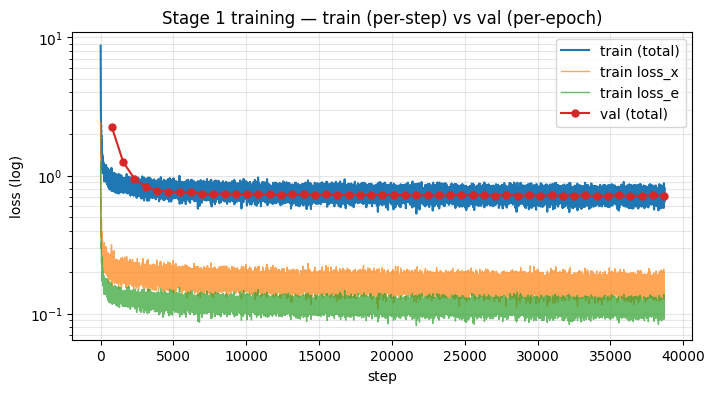

In [4]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 4))
plt.semilogy(history["step"], history["loss"],   label="train (total)", lw=1.5)
plt.semilogy(history["step"], history["loss_x"], label="train loss_x", lw=1, alpha=0.7)
plt.semilogy(history["step"], history["loss_e"], label="train loss_e", lw=1, alpha=0.7)
# val_loss is per-epoch; anchor each marker at the last training step of its epoch.
n_epochs = len(history["val_loss"])
if n_epochs > 0:
    steps_per_epoch = max(len(history["step"]) // n_epochs, 1)
    val_x = [(e + 1) * steps_per_epoch - 1 for e in range(n_epochs)]
    plt.semilogy(val_x, history["val_loss"], "o-", label="val (total)", lw=1.5, ms=5)
plt.xlabel("step")
plt.ylabel("loss (log)")
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.title("Stage 1 training — train (per-step) vs val (per-epoch)")
plt.show()


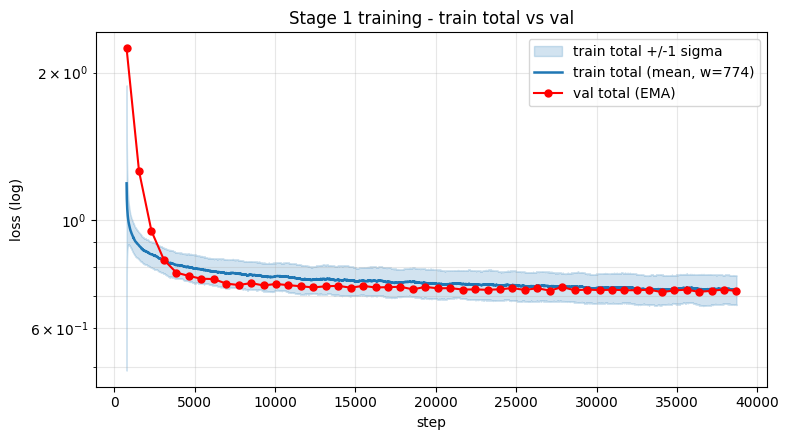

Final rolling-window values (w = 774 steps = 1 epoch)
  train total      loss=0.7202   std=0.0498 sigma/mu=6.92%
  val total (EMA)  loss=0.7155


In [15]:
import numpy as np
import matplotlib.pyplot as plt

def rolling_stats(y, w):
    # Right-aligned rolling mean and std over window w; length len(y)-w+1.
    y = np.asarray(y, dtype=float)
    mean = np.convolve(y, np.ones(w) / w, mode="valid")
    mean_sq = np.convolve(y * y, np.ones(w) / w, mode="valid")
    var = np.clip(mean_sq - mean ** 2, 0.0, None)   # clip tiny FP negatives
    return mean, np.sqrt(var)

n_epochs = len(history["val_loss"])
steps_per_epoch = max(len(history["step"]) // max(n_epochs, 1), 1)
w = steps_per_epoch                          # 1-epoch smoothing window
steps = np.asarray(history["step"])
x_roll = steps[w - 1:]

mean_tot, std_tot = rolling_stats(history["loss"], w)

# --- Loss: train total (rolling mean +/-1 sigma) vs val --------------------
plt.figure(figsize=(8, 4.5))
plt.fill_between(x_roll, np.clip(mean_tot - std_tot, 1e-6, None), mean_tot +
std_tot,
                  color="C0", alpha=0.20, label="train total +/-1 sigma")
plt.semilogy(x_roll, mean_tot, color="C0", lw=1.8, label=f"train total (mean, w={w})")
if n_epochs > 0:
    val_x = [(e + 1) * steps_per_epoch - 1 for e in range(n_epochs)]
    plt.semilogy(val_x, history["val_loss"], "o-", color="red", lw=1.5, ms=5,
                  label="val total (EMA)")
plt.xlabel("step")
plt.ylabel("loss (log)")
plt.title("Stage 1 training - train total vs val")
plt.legend(loc="upper right")
plt.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()

# --- Values (final rolling window) -----------------------------------------
cv = std_tot[-1] / mean_tot[-1] if mean_tot[-1] > 0 else float("nan")
print(f"Final rolling-window values (w = {w} steps = 1 epoch)")
print("=" * 52)
print(f"  {'train total':<16} loss={mean_tot[-1]:.4f}   std={std_tot[-1]:.4f} sigma/mu={cv:.2%}")
if n_epochs > 0:
    print(f"  {'val total (EMA)':<16} loss={history['val_loss'][-1]:.4f}")


## QM9 — Evaluate (V/U/N + FCD)


In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
out = evaluate.evaluate(model, size_sampler, train_smiles, atom_vocab, k_X, k_E,
                        n_samples=10000, batch=256, steps=100,
                        t_end=0.95, repair=False, fcd_ref=test_smiles,
                        device=device)
print(out)   # validity / uniqueness / novelty / repair_rate / fcd


## QM9 — Generated molecules (visual sample)


  0: CC(C=O)C(O)C#N
  1: COC(N)C=CCO
  2: O=C(CO)C1CCC1O
  3: C=CN1CC(=N)C(=O)C1
  4: CCNCC=O
  5: C#CC1CCC1
  6: OCC1COCCCN1
  7: C#CC1CC2N1C2(C)O
  8: CC#CC(C)(C)O
  9: O=CCN(O)NC1=CC1 (rep)
  10: CC=C1CC(C)(O)C1
  11: CN1C2C3OC3(C)C21C


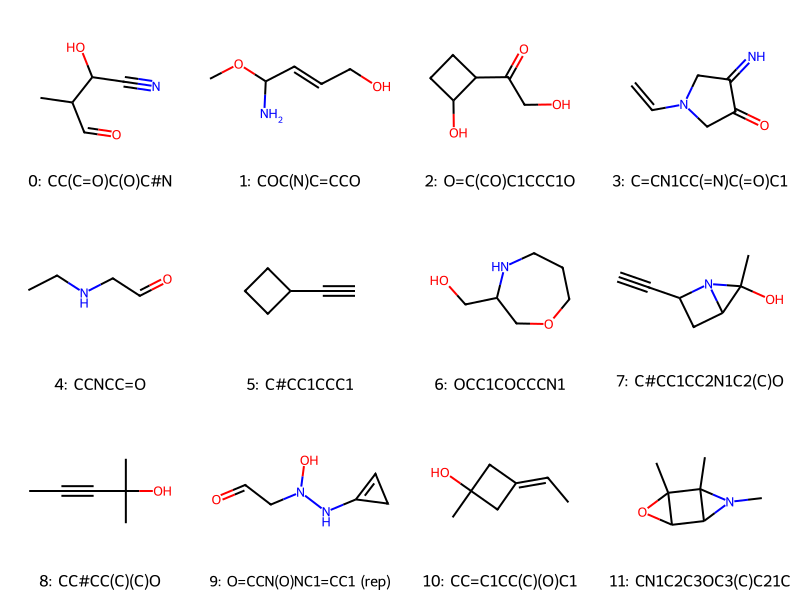

In [20]:
import torch
from rdkit import Chem
from rdkit.Chem import Draw
from IPython.display import display
from dataset.featurize import tensor_to_mol, largest_fragment
from flow import sample

n_show = 12
n_list = size_sampler.sample(n_show)
with torch.no_grad():
    X_oh, E_oh, mask = sample(model, n_list, k_X, k_E, steps=100, device=device)

mols, legends = [], []
for i in range(n_show):
    n = int(mask[i].sum().item())
    m, was_repaired = tensor_to_mol(X_oh[i, :n].cpu(), E_oh[i, :n, :n].cpu(), atom_vocab)
    m = largest_fragment(m)
    smi = Chem.MolToSmiles(m) if m is not None else "INVALID"
    mols.append(m)
    legends.append(f"{i}: {smi}" + (" (rep)" if was_repaired else ""))
    print(f"  {legends[-1]}")

valid = [(m, l) for m, l in zip(mols, legends) if m is not None]
if valid:
    valid_mols, valid_legends = zip(*valid)
    display(Draw.MolsToGridImage(list(valid_mols), molsPerRow=4, subImgSize=(200, 200),
                                 legends=list(valid_legends)))
else:
    print("No valid mols to render.")


## ZINC — Train
Auto-resumes from the last checkpoint and pushes checkpoints to `push_repo`
(local path is implicit). `save_every` is the checkpoint cadence in epochs.

In [ ]:
(model, history, size_sampler, train_smiles, atom_vocab,
 k_X, k_E, test_smiles) = train.train(
    dataset="zinc", epochs=5, batch_size=128, subset=20000,
    push_repo="nico8771/zinc_stage1_fm", save_every=2)


## ZINC — Loss curves


In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 4))
plt.semilogy(history["step"], history["loss"],   label="train (total)", lw=1.5)
plt.semilogy(history["step"], history["loss_x"], label="train loss_x", lw=1, alpha=0.7)
plt.semilogy(history["step"], history["loss_e"], label="train loss_e", lw=1, alpha=0.7)
n_epochs = len(history["val_loss"])
if n_epochs > 0:
    steps_per_epoch = max(len(history["step"]) // n_epochs, 1)
    val_x = [(e + 1) * steps_per_epoch - 1 for e in range(n_epochs)]
    plt.semilogy(val_x, history["val_loss"], "o-", label="val (total)", lw=1.5, ms=5)
plt.xlabel("step")
plt.ylabel("loss (log)")
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.title("Stage 1 ZINC training — train (per-step) vs val (per-epoch)")
plt.show()


## ZINC — Evaluate (V/U/N)


In [ ]:
# ZINC V/U/N (VUN-only). To also get FCD here, reload with split_subset=20000
# in the reload cell (or reuse the test set returned by the ZINC train cell) and
# pass it as the FCD reference, mirroring the QM9 cell above.
device = 'cuda' if torch.cuda.is_available() else 'cpu'
vun = evaluate.evaluate(model, size_sampler, train_smiles, atom_vocab,
                        k_X, k_E, n_samples=1000, batch=256, steps=100,
                        device=device)
print(vun)


## ZINC — Generated molecules (visual sample)


In [ ]:
import torch
from rdkit import Chem
from rdkit.Chem import Draw
from IPython.display import display
from dataset.featurize import tensor_to_mol, largest_fragment
from flow import sample

n_show = 12
n_list = size_sampler.sample(n_show)
with torch.no_grad():
    X_oh, E_oh, mask = sample(model, n_list, k_X, k_E, steps=100, device=device)

mols, legends = [], []
for i in range(n_show):
    n = int(mask[i].sum().item())
    m, was_repaired = tensor_to_mol(X_oh[i, :n].cpu(), E_oh[i, :n, :n].cpu(), atom_vocab)
    m = largest_fragment(m)
    smi = Chem.MolToSmiles(m) if m is not None else "INVALID"
    mols.append(m)
    legends.append(f"{i}: {smi}" + (" (rep)" if was_repaired else ""))
    print(f"  {legends[-1]}")

valid = [(m, l) for m, l in zip(mols, legends) if m is not None]
if valid:
    valid_mols, valid_legends = zip(*valid)
    display(Draw.MolsToGridImage(list(valid_mols), molsPerRow=4, subImgSize=(200, 200),
                                 legends=list(valid_legends)))
else:
    print("No valid mols to render.")
